In [1]:
import pandas as pd

df = pd.read_json('/home/bartosz-linux/study/bcmp-networks/logs/OYzE4Lhqbl.jsonl', lines=True)


In [2]:
df

,source,ts,action,request_id,type,dest_id,new_type
0,WS 1,00:00:057,received,1502,Stabilny,NaN,NaN
1,WS 1,00:00:057,queued,1502,Stabilny,NaN,NaN
2,GN 3,00:00:057,generated,1502,Stabilny,NaN,NaN
3,WS 1,00:00:057,started,1502,Stabilny,NaN,NaN
4,WS 5,00:00:183,received,1503,Symulant,NaN,NaN
...,...,...,...,...,...,...,...
2484,WS 1,00:59:554,queued,1802,Stabilny,NaN,NaN
2485,GN 3,00:59:554,generated,1802,Stabilny,NaN,NaN
2486,WS 1,00:59:793,received,1803,Symulant,NaN,NaN
2487,WS 1,00:59:793,rejected,1803,Symulant,NaN,NaN


In [3]:
# Convert the timestamp 'ts' column to a standard datetime.timedelta format for easy time calculations
import numpy as np
import datetime as dt
def avg_requests_per_class(df):
# Convert 'ts' to timedelta
    def parse_timestamp(ts):
        try:
            minutes, seconds, milliseconds = map(int, ts.split(':'))
            return dt.timedelta(minutes=minutes, seconds=seconds, milliseconds=milliseconds)
        except:
            return np.nan

    
    df['ts'] = df['ts'].apply(parse_timestamp)

    # Filter relevant rows for each calculation by actions
    # Extracting queueing and processing stages
    queued_df = df[df['action'] == 'queued']
    started_df = df[df['action'] == 'started']
    processed_df = df[df['action'] == 'processed']

    # Calculating average number of requests by class and server
    avg_requests_per_class_server = df.groupby(['source', 'type'])['request_id'].nunique().groupby(level=0).mean()


    # Combining results into a single DataFrame for presentation
    results_df = pd.DataFrame({
        'avg_requests_per_class': avg_requests_per_class_server,
    }).reset_index()


    return results_df

avg_requests_per_class(df)
    

,source,avg_requests_per_class
0,GN 2,47.000000
1,GN 3,54.000000
2,GN 4,74.000000
3,GN 6,62.000000
4,GN 7,65.000000
5,WS 1,58.333333
6,WS 5,76.500000
7,WS 8,18.000000
8,WS 9,11.500000
9,WS10,32.500000


Processing data for source: WS 1
    request_id  processing_time       type new_type
0   1502_3_nan            1.050   Stabilny   yellow
1   1505_3_nan            1.032  Krytyczny      red
2   1507_3_nan            1.481  Krytyczny      red
3   1508_3_nan            1.251   Symulant    green
4   1509_3_nan            1.673  Krytyczny      red
5   1511_3_nan            4.647  Krytyczny      red
6   1512_3_nan            6.280   Symulant    green
7   1513_3_nan            6.974   Stabilny   yellow
8   1515_3_nan            6.280   Symulant    green
9   1516_3_nan            6.815   Symulant    green
10  1518_3_nan            9.314   Symulant    green
11  1519_3_nan           10.251   Symulant    green
12  1521_3_nan           10.749   Stabilny   yellow
13  1523_3_nan           11.669   Symulant    green
14  1525_3_nan           21.389   Stabilny   yellow
15  1526_3_nan           21.912  Krytyczny      red
16  1527_3_nan           21.915   Stabilny   yellow
17  1528_3_nan           22.348

/tmp/ipykernel_9960/1788804160.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_subset['ts'] = pd.to_timedelta(data_subset['ts'])


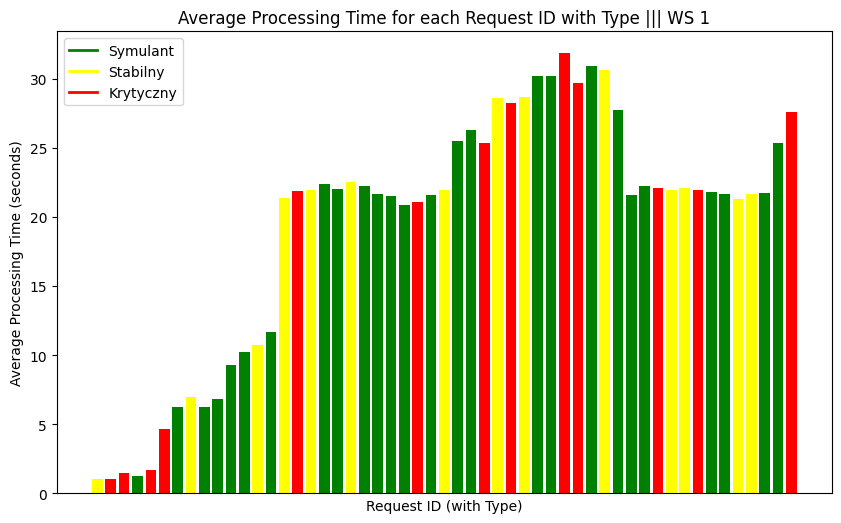

Processing data for source: WS 5
    request_id  processing_time      type new_type
0   1503_3_nan            1.381  Symulant    green
1   1504_3_nan            1.703  Stabilny   yellow
2   1506_3_nan            2.089  Symulant    green
3   1508_3_nan            2.538  Symulant    green
4   1510_3_nan            3.046  Stabilny   yellow
..         ...              ...       ...      ...
60  1668_3_nan           21.476  Symulant    green
61  1680_3_nan           21.439  Symulant    green
62  1694_3_nan           20.060  Symulant    green
63  1697_3_nan           20.538  Stabilny   yellow
64  1698_3_nan           21.763  Symulant    green

[65 rows x 4 columns]


/tmp/ipykernel_9960/1788804160.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_subset['ts'] = pd.to_timedelta(data_subset['ts'])


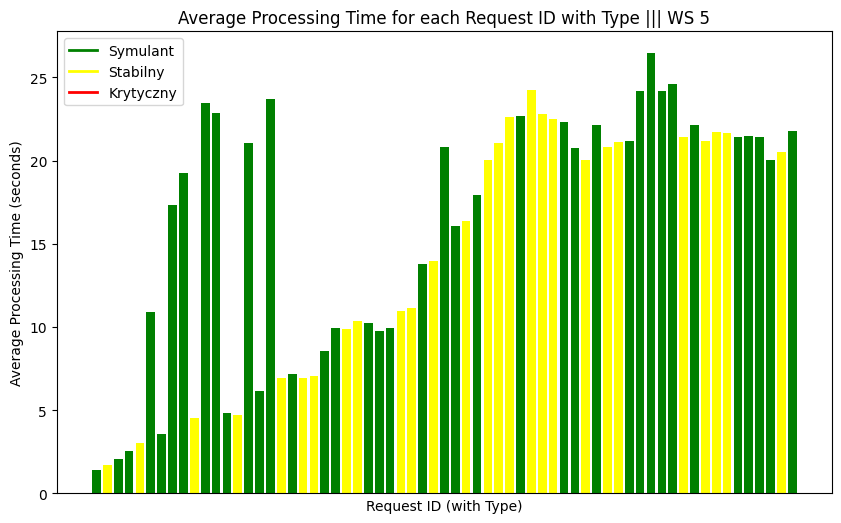

Processing data for source: WS 9
     request_id  processing_time      type new_type
0    1502_2_nan            0.777  Stabilny   yellow
1    1502_6_nan            0.297  Stabilny   yellow
2    1504_2_nan            0.057  Stabilny   yellow
3    1513_2_nan            0.645  Stabilny   yellow
4    1513_6_nan            1.408  Stabilny   yellow
5   1513_10_nan            0.093  Stabilny   yellow
6    1521_2_nan            0.561  Stabilny   yellow
7    1521_6_nan            1.541  Stabilny   yellow
8    1525_2_nan            1.673  Stabilny   yellow
9    1527_2_nan            0.649  Stabilny   yellow
10   1527_6_nan            0.207  Stabilny   yellow
11  1527_10_nan            2.285  Stabilny   yellow
12  1527_14_nan            0.195  Stabilny   yellow
13  1527_18_nan            0.411  Stabilny   yellow
14   1532_2_nan            0.515  Stabilny   yellow
15   1535_2_nan            1.935  Stabilny   yellow
16   1545_2_nan            0.476  Stabilny   yellow
17   1545_6_nan            0.60

/tmp/ipykernel_9960/1788804160.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_subset['ts'] = pd.to_timedelta(data_subset['ts'])


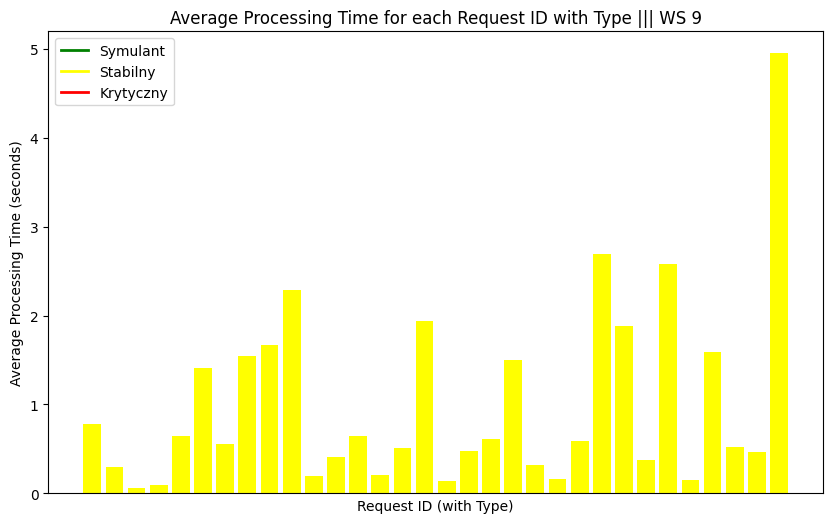

Processing data for source: WS 8
No valid processing times for source subset.
Processing data for source: WS10
    request_id  processing_time      type new_type
0   1503_2_nan            2.243  Symulant    green
1   1504_2_nan            0.308  Stabilny   yellow
2   1506_2_nan            0.538  Symulant    green
3   1508_2_nan            2.946  Symulant    green
4   1510_2_nan            1.137  Stabilny   yellow
..         ...              ...       ...      ...
60  1668_2_nan            0.139  Symulant    green
61  1680_2_nan            0.323  Symulant    green
62  1694_2_nan            0.356  Symulant    green
63  1697_2_nan            1.344  Stabilny   yellow
64  1698_2_nan            0.193  Symulant    green

[65 rows x 4 columns]


/tmp/ipykernel_9960/1788804160.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_subset['ts'] = pd.to_timedelta(data_subset['ts'])
/tmp/ipykernel_9960/1788804160.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_subset['ts'] = pd.to_timedelta(data_subset['ts'])


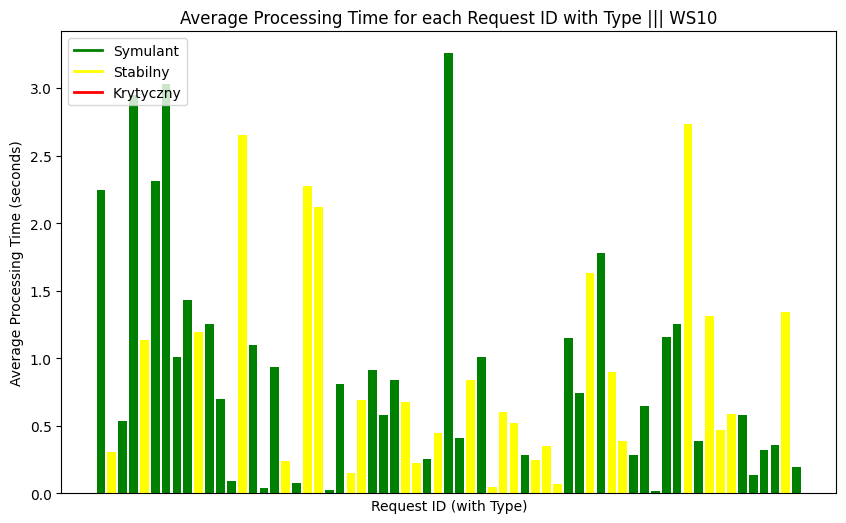

Processing data for source: WS11
     request_id  processing_time       type new_type
0    1502_3_nan            0.237   Stabilny   yellow
1    1502_9_nan            0.379   Stabilny   yellow
2    1504_3_nan            0.278   Stabilny   yellow
3    1513_3_nan            0.251   Stabilny   yellow
4    1513_8_nan            0.004   Stabilny   yellow
5   1513_13_nan            0.269   Stabilny   yellow
6    1521_3_nan            1.167   Stabilny   yellow
7    1521_8_nan            0.773   Stabilny   yellow
8    1525_3_nan            1.778   Stabilny   yellow
9    1527_3_nan            2.065   Stabilny   yellow
10   1527_8_nan            0.988   Stabilny   yellow
11  1527_13_nan            1.887   Stabilny   yellow
12  1527_18_nan            0.154   Stabilny   yellow
13  1527_23_nan            1.777   Stabilny   yellow
14   1532_3_nan            3.100   Stabilny   yellow
15   1535_3_nan            0.081   Stabilny   yellow
16   1545_3_nan            0.939   Stabilny   yellow
17   1545_8_n

/tmp/ipykernel_9960/1788804160.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_subset['ts'] = pd.to_timedelta(data_subset['ts'])


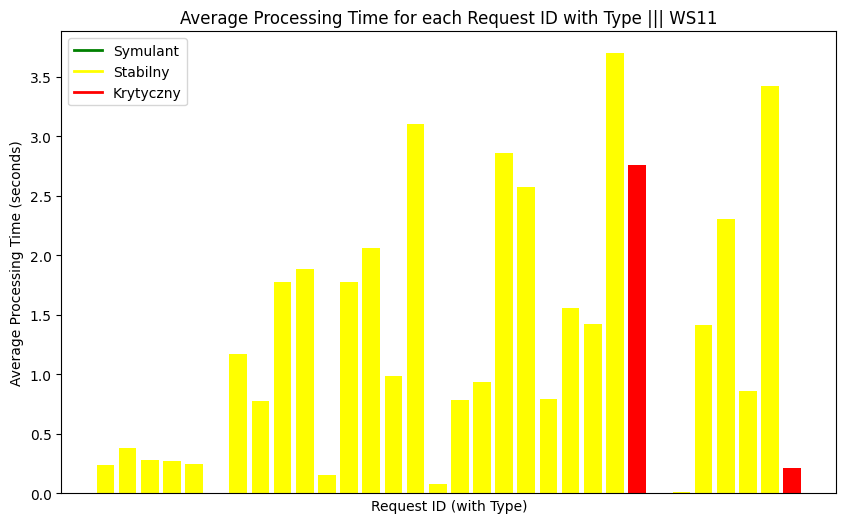

Processing data for source: WS13


/tmp/ipykernel_9960/1788804160.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_subset['ts'] = pd.to_timedelta(data_subset['ts'])


     request_id  processing_time      type new_type
0    1502_3_nan            0.335  Stabilny   yellow
1    1504_3_nan            0.505  Stabilny   yellow
2    1513_3_nan            1.317  Stabilny   yellow
3    1513_8_nan            0.787  Stabilny   yellow
4    1521_3_nan            1.187  Stabilny   yellow
5    1527_3_nan            2.389  Stabilny   yellow
6    1527_8_nan            4.941  Stabilny   yellow
7   1527_13_nan            2.101  Stabilny   yellow
8   1527_18_nan            1.431  Stabilny   yellow
9    1535_3_nan            1.796  Stabilny   yellow
10   1545_3_nan            1.302  Stabilny   yellow
11   1545_8_nan            0.481  Stabilny   yellow
12  1545_13_nan            3.689  Stabilny   yellow
13   1548_3_nan            1.059  Stabilny   yellow
14   1548_8_nan            4.133  Stabilny   yellow
15   1550_3_nan            2.569  Stabilny   yellow
16   1559_3_nan            0.191  Stabilny   yellow
17   1579_3_nan            0.951  Stabilny   yellow


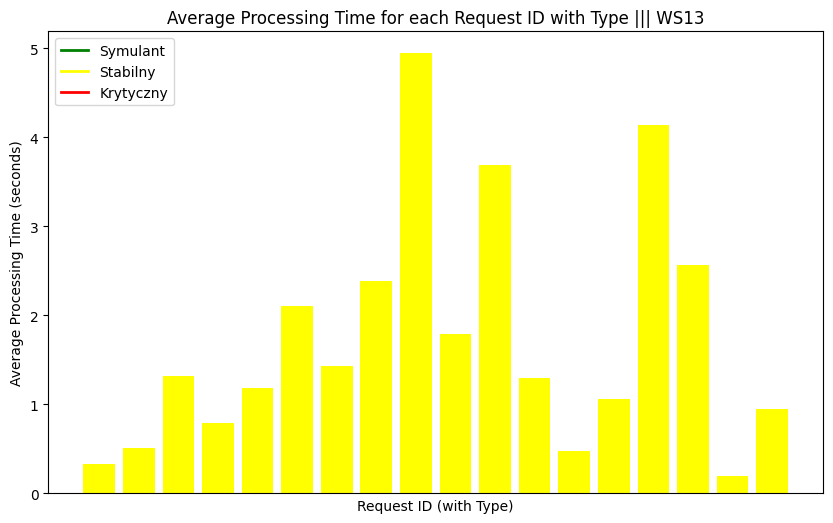

Processing data for source: WS12
    request_id  processing_time      type new_type
0   1504_3_nan            1.373  Stabilny   yellow
1   1510_3_nan            2.195  Stabilny   yellow
2   1517_3_nan            4.064  Stabilny   yellow
3   1522_3_nan            4.126  Stabilny   yellow
4   1533_3_nan            2.874  Stabilny   yellow
5   1535_3_nan            2.769  Stabilny   yellow
6   1540_3_nan            4.453  Stabilny   yellow
7   1542_4_nan            5.355  Symulant    green
8   1545_4_nan            6.554  Symulant    green
9   1546_3_nan            9.282  Stabilny   yellow
10  1548_3_nan            7.536  Stabilny   yellow
11  1550_3_nan            8.789  Stabilny   yellow
12  1556_3_nan            9.139  Stabilny   yellow
13  1560_3_nan            8.510  Stabilny   yellow
14  1568_4_nan            7.706  Symulant    green
15  1579_3_nan           10.278  Stabilny   yellow
16  1583_3_nan            9.622  Stabilny   yellow
17  1597_3_nan           11.052  Stabilny   yello

/tmp/ipykernel_9960/1788804160.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_subset['ts'] = pd.to_timedelta(data_subset['ts'])


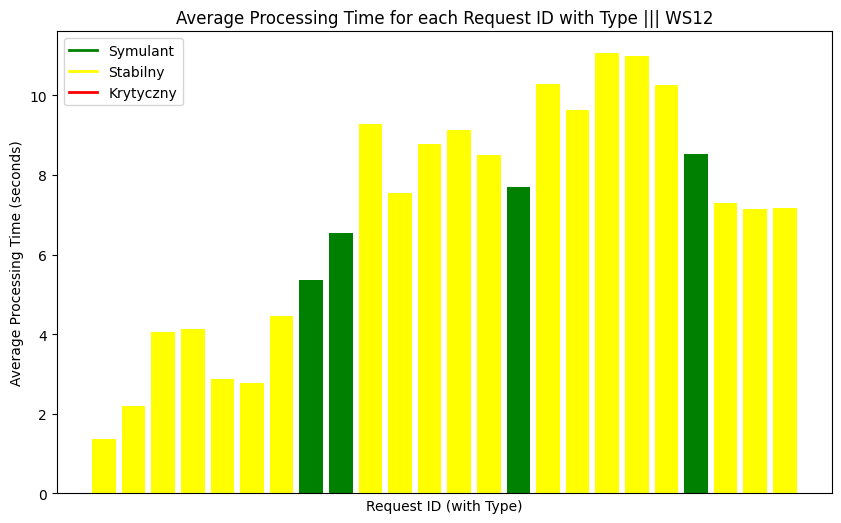

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D

def plot_avg_time_request_server_with_type(data_subset, server_name):
    # Konwersja 'ts' na timedelta
    data_subset['ts'] = pd.to_timedelta(data_subset['ts'])
    # print(data_subset)
    data_subset = data_subset.sort_values(by=['request_id', 'ts'])

    processing_intervals = []
    new_request_id = None

    type_color_mapping = {
            "Symulant": "green",
            "Stabilny": "yellow",
            "Krytyczny": "red"
    }

    for request_id, group in data_subset.groupby('request_id'):
        group = group.reset_index(drop=True)
        last_type = None
        for i, row in group.iterrows():
            if row['action'] == 'received' or (last_type and row.get('new_type') != last_type):
                current_type = row.get('new_type') if row.get('new_type') else 'initial'
                new_request_id = f"{request_id}_{i}_{current_type}"
                
            if row['action'] == 'received':
                start_time = row['ts']
                last_type = row['type']
            
            elif row['action'] in ['forwarded', 'rejected']:
                end_time = row['ts']
                processing_time = (end_time - start_time).total_seconds()

                if processing_time > 0:
                    processing_intervals.append({
                        'request_id': new_request_id, 
                        'processing_time': processing_time, 
                        'type': last_type
                    })
                    
                last_type = row.get('new_type', 'initial')

    processing_intervals_df = pd.DataFrame(processing_intervals)
    
    if not processing_intervals_df.empty:
        processing_intervals_df['new_type'] = processing_intervals_df['type'].map(type_color_mapping)
        # 
        average_processing_time_df = processing_intervals_df.groupby(['request_id', 'new_type'])['processing_time'].mean().reset_index()
        
        colors = average_processing_time_df['new_type']
        
        plt.figure(figsize=(10, 6))
        plt.bar(average_processing_time_df['request_id'], average_processing_time_df['processing_time'], color=colors)
        plt.xlabel('Request ID (with Type)')
        plt.ylabel('Average Processing Time (seconds)')
        plt.title(f'Average Processing Time for each Request ID with Type ||| {server_name}')
        
        legend_elements = [
        Line2D([0], [0], color="green", lw=2, label="Symulant"),
        Line2D([0], [0], color="yellow", lw=2, label="Stabilny"),
        Line2D([0], [0], color="red", lw=2, label="Krytyczny")
    ]

        plt.legend(handles=legend_elements, loc="upper left")

        plt.xticks([], [])  
        plt.show()
    else:
        print(f"No valid processing times for source subset.")

for source in df['source'].unique():
    if "WS" in source:
        data_subset = df[df['source'] == source]
        print(f"Processing data for source: {source}")
        plot_avg_time_request_server_with_type(data_subset, server_name=source)
# source = 'WS 1'
# data_subset = df[df['source'] == source]
# plot_avg_time_request_server_with_type(data_subset, server_name=source)
